**IMPORTANT NOTES:** 
1. Before running this notebook, please ensure you have downloaded the appropriate libraries, such as rasterio (a remote sensing and image processing library), seaborn, and tqdm.
2. Only run the Initial Raw Data Processing cells if you want to run things starting from the raw 3 GB dataset. This is NOT recommended for most computers given the high computational load required. To do so, please ensure to extract the EuroSATallBands zip file to a fresh folder and use this as the input path (input_path) in the Initial Raw Data Processing section. If NOT running the Initial Raw Data Processing cells, only run the imports cell and then please skip to the Data Processing Using Subset of Raw Data section that follows the Initial Raw Data Processing section, using the "eurosat_data_subset_100_000_pixels.npz" file.

In [1]:
NAME = "GROUP 1"
COLLABORATORS = "Craig Vande Ligt, Collin Potter-Bonar, Anca Rotaru, Rob Mifsud, Akshaya Ramanarayanan, Bhavin Prajapat"
PROPOSED_TITLE = "Machine Learning Group 1: Comparing Random Forest, Support Vector, and K-Nearest Neighbors Classifiers on Sentinel-2 Satellite Imagery"

**INFORMATION**: \
Dataset: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset?resource=download-directory&select=EuroSATallBands \
Sentinel-2 bands: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/

**PROJECT PROPOSAL** \
The dataset contains a ton of 64x64 10m pixel 13-band image tiles (we are only concerned with 4 bands: blue, green, red, near-infrared) from the Sentinel-2 satellite that is used for Earth observation, equating to 2.84 GB for all 13 bands (113,037,312 pixels for just the 4 bands) of data.

The goal of the project is to optimize and run Random Forest, Support Vector, and k-Nearest Neighbor Classifiers on the Sentinel-2 satellite imagery and determine how well each optimized classifier did compared to the target data. Comparisons between the performance of these classifiers will be discussed, as well as determine which model performed the best and why. 

**Project Workflow:**
1. Read in data and put data into X and y
2. Take stratified subset of raw X and y data and save it as a .npz file
3. Read in the .npz 100,000 pixel X and y subset file
4. Split X and y using train-test-split
5. Create optimized RFC based on hyperparameter tuning using random search cv
   1. Create RFC with random_state=12
   2. Create RFC parameters dictionary
   3. Run RandomizedSearchCV on RFC using RFC parameters (set n_jobs to 10 to balance parallization vs # of available threads on CPU)
   4. Fit on X_train and y_train (get runtime of fitting procedure)
   5. Get best_estimator_, best_params_
   6. Get accuracy using accuracy_score
6. Do the above for SVM
7. Do the above for KNN
8. Evaluate models via checking precision, recall, f1-score, and plotting the ROC AUC curves to get AUC values and check if models are any good (doing this after building each optimized hyperparameters models to keep Notebook looking clean). Do this as using a function and calling function on each model.  
9. Evaluate models against eachother, recognizing each models linear or non-linear approach, advantages/disadvantages, and why one works better than the others for image classification. 
   

In [ ]:
# To initialize Intelex requirement, which should improve process speeds for models
# You may already have threadpoolctl, version 3.6.0.
#To install, please run the following and remember to restart the kernel before proceeding:
#conda install threadpoolctl
#conda install -c conda-forge scikit-learn-intelex

In [2]:
# Installing libraries
# Intelex's sklearnex should accelerate model performance
from threadpoolctl import threadpool_info, ThreadpoolController
import threadpoolctl
from sklearnex import patch_sklearn
patch_sklearn()

#List of imports for entire project
import os
import psutil
import platform
import numpy as np
import pandas as pd
import time
import rasterio as rio
import matplotlib.pyplot as plt
import seaborn as sns
import glob #Used to find all GeoTIFF files in a specified folder
from tqdm import tqdm #Used to get progress bar while processing data
import multiprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, auc, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline # New to notebook
from sklearn.preprocessing import StandardScaler # New to notebook
from scipy.stats import randint, uniform # New to notebook
from itertools import cycle
from sklearn.tree import plot_tree
from collections import defaultdict

%matplotlib inline

#Setup n_jobs for parallization of random search of RFC
def get_safe_n_jobs(reserve=4):
    physical_cores = psutil.cpu_count(logical=False)
    os_type = platform.system()
    print("Detected OS: {}".format(os_type))
    print("Detected physical cores: {}".format(physical_cores))
    return max(1, physical_cores - reserve)

n_jobs = get_safe_n_jobs()
print("n_jobs for random search of RFC, SVC, and KNN models set to:", n_jobs)

rng = np.random.default_rng(seed=12)

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


Detected OS: Windows
Detected physical cores: 16
n_jobs for random search of RFC, SVC, and KNN models set to: 12


**IMPORTANT NOTE**: Only run the initial raw data processing cells if you want to run things starting from the raw 3 GB dataset. This is NOT recommended for most computers given the high computational load required. Please consider skipping this section and running things starting with the Data Processing Using Subset of Raw Data section and the "eurosat_data_subset_100_000_pixels.npz" file.

# Initial Raw Data Processing (Only run if you don't have the .npz file)

In [ ]:
#NOTE: This cell may take 10-15 minutes to run. Parallelizing it may improve times, but risks inputting data
#      into the lists in incorrect order. While this technically does not matter in the end, I don't want
#      to risk messing things up after getting it working now.
#Setup data for reading into rasterio
input_path = r"D:\Machine_Learning_for_DataScience_Waterloo\Group Project\EuroSATallBands"
output_path = r"D:\Machine_Learning_for_DataScience_Waterloo\Group Project\eurosat_data_subset_100_000_pixels.npz"

band_indices = [1, 2, 3, 7] #Rasterio is 0-indexed. We want the blue, green, red, and near-infrared bands

#Create blank X and y lists
X = []
y = []

#Get classifiication/target labels
class_labels = sorted([d for d in os.listdir(input_path) if os.path.isdir(os.path.join(input_path, d))])
print("Class Labels:", class_labels)

#Read in imagery (64x64 10m GSD pixel image tiles) and extract pixel values for the 4 bands mentioned above (band_indices)
for class_index, class_name in enumerate(class_labels):
    class_folder = os.path.join(input_path, class_name)
    img_files = glob.glob(os.path.join(class_folder, "*tif")) #Searches for GeoTIFFs in each class folder
    for img_file in tqdm(img_files, desc="Processing {}".format(class_name), unit="Images"):
        with rio.open(img_file) as src:
            img = src.read(band_indices) #Shape = (4, 64, 64)
        img = np.moveaxis(img, 0, -1) #Shape changed to (64, 64, 4)
        pixels = img.reshape(-1, 4) #Change shape to be a 2D array (row = single pixel (combines 64x64 from 2D to 1D of 4096 pixels), col = band value (b,g,r, or nir)
        X.append(pixels)
        y.append(np.full((pixels.shape[0],), class_index)) #pixels.shape[0] gives the 4096 pixels; class_index is the assigned class label to the given pixel

#Flatten lists of X and y into arrays to be used for ML classifiers (rows = pixels, columns = bands, values = class/label/landcover type)
X = np.vstack(X) #Using vstack since X is a 2D array and we want to vertically stack the arrays into a single array. I.e. puts all pixels into 4 columns, one per band
y = np.hstack(y) #Using hstack since y is a horizontal array (concatenates into one long vector). I.e. per pixel gives class label (1 column)

Note that since we grabbed the class label for each pixel based on the EuroSATallBands subfolders, and plan to do our own train-test-split, we do NOT need to use the test, train, or validation csv files provided in the EuroSATallBands directory. 

In [ ]:
X.shape

Given the sure size of the raw 4-band GeoTIFF dataset (~113 million pixels) and the limitations on power a laptop has for processing such a dataset, let alone developing optimized models using enough folds, it would be reasonable to reduce the dataset to a total of 100,000 pixels, ensuring the number of pixels per class is representative/proportional per class in the raw dataset (i.e. done using stratified sampling). The following cell does that.

In [ ]:
sample_size = 100000 #200,000 #500,000 pixels

#Get number of pixels for each class so we can ensure stratified sampling
classes, class_counts = np.unique(y, return_counts=True)
proportions_by_class = class_counts / class_counts.sum()
samples_per_class = (proportions_by_class * sample_size).astype(int) #Get number of samples per class

X_subset = []
y_subset = []
for class_, n_samples in zip(classes, samples_per_class):
    class_indices = np.where(y == class_)[0] #Get indices where y is the current class (class_); [0] indicates we want where the conditional is true
    indices_chosen = rng.choice(class_indices, n_samples, replace=False) #Select unique proportional random samples (no duplicates allowed)
    X_subset.append(X[indices_chosen])
    y_subset.append(y[indices_chosen])

#Perform vertical and horizontal restacking of the X and y subsets, respectively
X_subset = np.vstack(X_subset)
y_subset = np.hstack(y_subset)

#Shuffle rows for subset of X and y data to prevent poor cross-validations/model failure due to rows ordered by class (due to for-loop)
#Using perm on X and y subsets to ensure they both have same order/they remain paired
perm = rng.permutation(len(X_subset))
X_subset = X_subset[perm]
y_subset = y_subset[perm]

#Save data to compressed numpy archive file
np.savez_compressed(output_path, X=X_subset, y=y_subset, class_labels=class_labels)

# Data Processing Using Subset of Raw Data (Using .npz file)

Due to the sure size of the raw GeoTIFF dataset (~2.8 GB, 4-band: ~113 million pixels) and the limited power some laptops have to processes such a dataset, let alone developing optimized models using enough folds, we reduced the dataset to a total of 100,000 pixels using the above cells, ensuring that the number of pixels per class is representative/proportional per class in the raw dataset (i.e. We used stratified sampling). The data was then saved out to a compressed numpy archive (.npz) to ensure quick read-in times of the X and y data, as well as the class labels. 

Below is the data processing and modeling our team worked on using this subset dataset.

In [3]:
input_path = r"D:\Machine_Learning_for_DataScience_Waterloo\Group Project\eurosat_data_subset_100_000_pixels.npz"
if os.path.exists(input_path):
    print("Loading cached X, y...")
    data = np.load(input_path, allow_pickle=True)
    X = data["X"]
    y = data["y"]
    class_labels = data["class_labels"].tolist()
    print("Subset dataset is read-in and ready to go")

Loading cached X, y...
Subset dataset is read-in and ready to go


In [4]:
X.shape

(99993, 4)

# Data Exploration

In [5]:
# 1. Feature Analysis
# Create a pandas dataframe for easier analysis and visualization
X_df = pd.DataFrame(X, columns=['blue', 'green', 'red', 'nir'])

# Get a statistical summary of the features
print("Statistical Summary of Pixel Values (X):")
print(X_df.describe())

Statistical Summary of Pixel Values (X):
               blue         green           red           nir
count  99993.000000  99993.000000  99993.000000  99993.000000
mean    1354.690788   1116.500895   1034.484034   2325.965248
std      242.019189    333.829689    398.303207   1113.968098
min      823.000000    566.000000    367.000000    136.000000
25%     1179.000000    887.000000    767.000000   1777.000000
50%     1312.000000   1042.000000    965.000000   2438.000000
75%     1475.000000   1271.000000   1211.000000   3025.000000
max     6051.000000  22687.000000  23486.000000  23167.000000


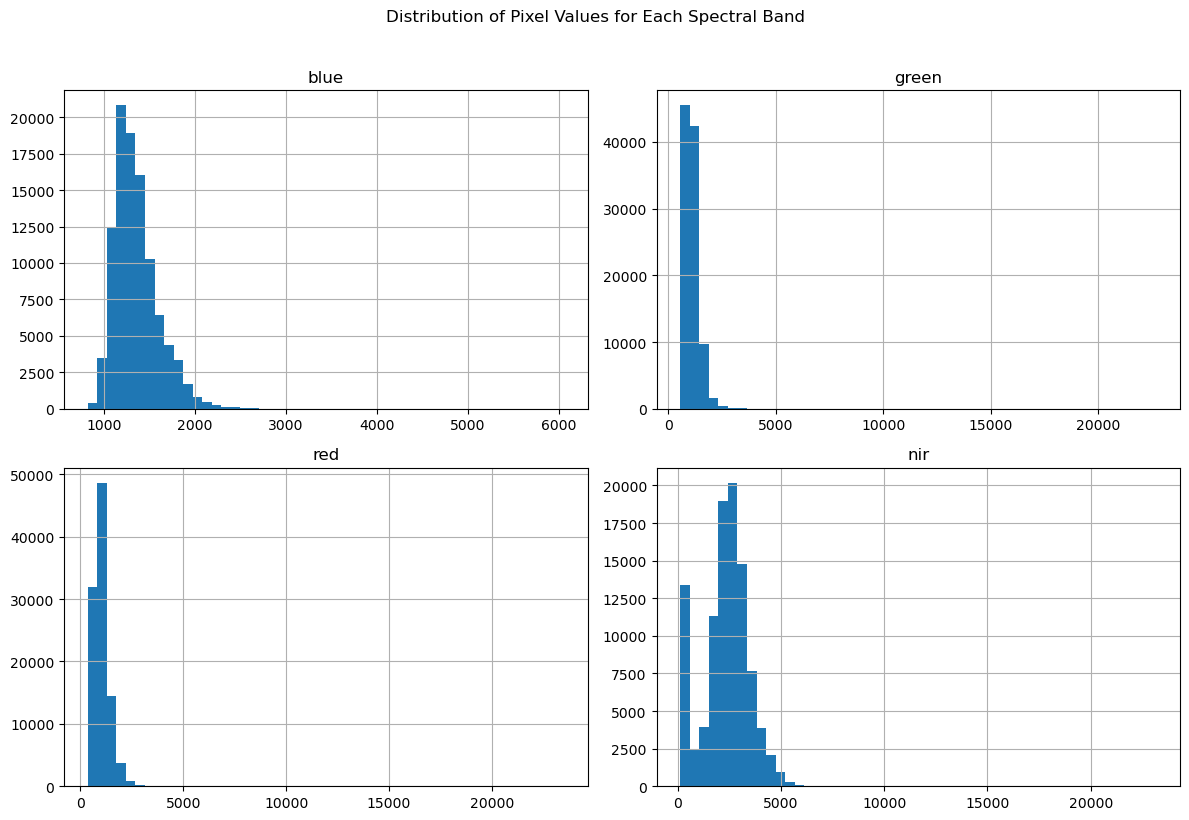

In [6]:
# Plot histograms to see the distribution of pixel values for each band
X_df.hist(figsize=(12, 8), bins=50)
plt.suptitle("Distribution of Pixel Values for Each Spectral Band", y=1.02)
plt.tight_layout()
plt.show()

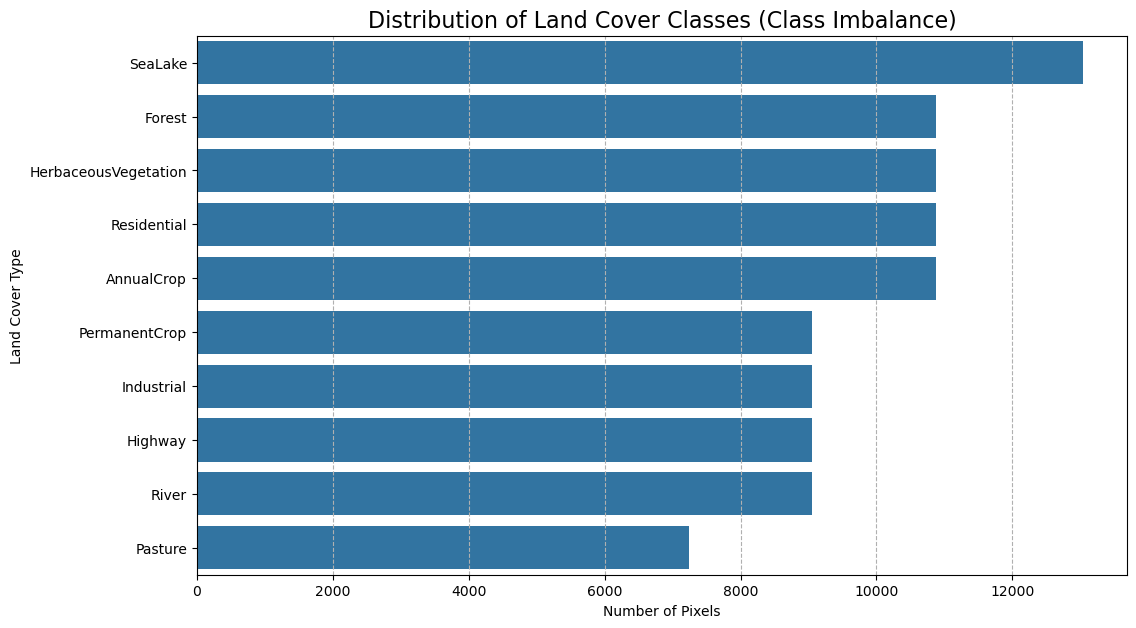

In [7]:
# 2. Target Class Analysis
# Convert the numeric labels in y to their string names for better plotting
y_named = [class_labels[i] for i in y]
y_series = pd.Series(y_named)

# A. Visual Analysis of Class Imbalance
plt.figure(figsize=(12, 7))
sns.countplot(y=y_series, order=y_series.value_counts().index)
plt.title('Distribution of Land Cover Classes (Class Imbalance)', fontsize=16)
plt.xlabel('Number of Pixels')
plt.ylabel('Land Cover Type')
plt.grid(axis='x', linestyle='--')
plt.show()

In [8]:
# Numerical Analysis to support stratification
print("\nClass Proportions in the Dataset:")
class_proportions = y_series.value_counts(normalize=True) * 100
for class_name, proportion in class_proportions.items():
    print(f"{class_name}: {proportion:.2f}%")


Class Proportions in the Dataset:
SeaLake: 13.03%
Forest: 10.87%
HerbaceousVegetation: 10.87%
Residential: 10.87%
AnnualCrop: 10.87%
PermanentCrop: 9.06%
Industrial: 9.06%
Highway: 9.06%
River: 9.06%
Pasture: 7.25%


In [9]:
# 3. Data Quality and Cleaning Checks
# Check for any missing values in the dataset
print("--- Missing Value Check ---")
print(X_df.isnull().sum())

--- Missing Value Check ---
blue     0
green    0
red      0
nir      0
dtype: int64



--- Outlier Visualization ---


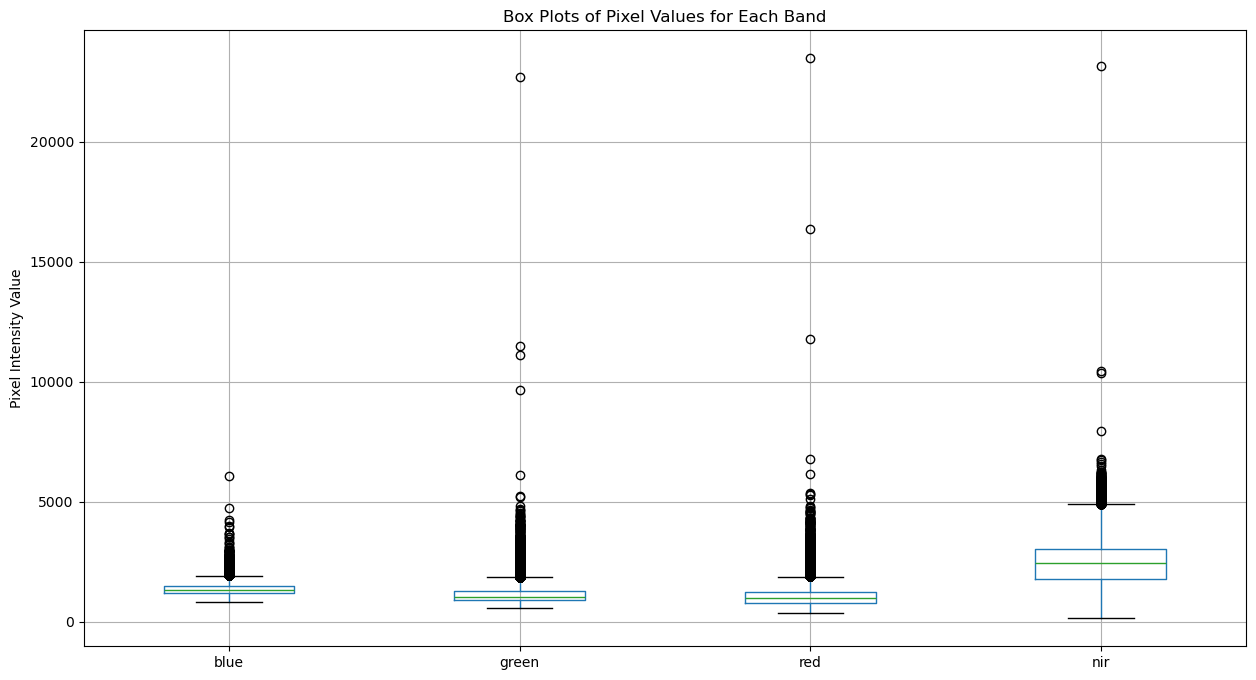

In [10]:
# Visualize potential outliers using box plots for each spectral band
print("\n--- Outlier Visualization ---")
plt.figure(figsize=(15, 8))
X_df.boxplot()
plt.title("Box Plots of Pixel Values for Each Band")
plt.ylabel("Pixel Intensity Value")
plt.show()


--- Correlation Matrix of Spectral Bands ---


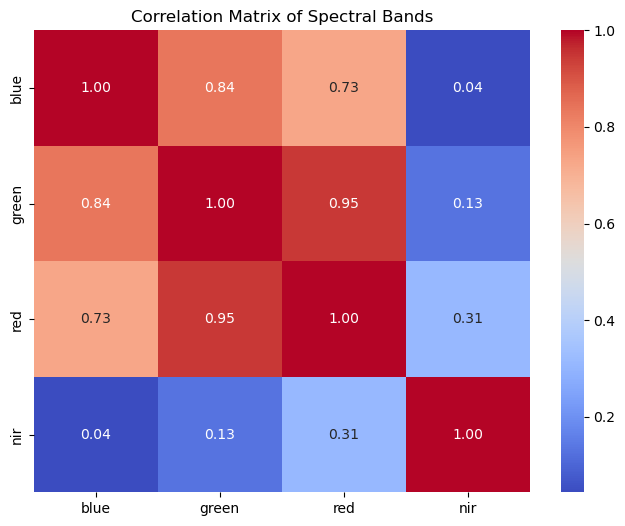

In [11]:
# 4. Feature Correlation Analysis
print("\n--- Correlation Matrix of Spectral Bands ---")

# Calculate the correlation matrix
corr_matrix = X_df.corr()

# Plot the correlation matrix as a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Spectral Bands")
plt.show()

### Data exploration observations:
1. **Data Quality and Feature Characteristics:** 
    * The dataset is of high quality, with no missing values and no extreme, erroneous outliers that would require removal.
    * The four features—the blue, green, red, and near-infrared spectral bands—are all numerical.
    * A correlation matrix revealed that the visible spectrum bands (red, blue, green) are as expected, highly positively correlated with each other. This suggest that tree-based models should be a good choice since they are robust to multicollinearity.
    * nir (near infrared) band, which is good for mapping shorelines and biomass content, as well as at detecting and analyzing vegetation, has a low correlation to the others, offering a powerful, semi-independent feature for our models to make accurate predictions.
    * The different spectral bands have different distributions and scales. This finding suggests that for more scale-sensitive models (SVC, KNN), it will be essential to use a StandardScaler within a Pipeline.  
  
2. **Target Class Distribution:** \
From the bar chart and numerical proportion we observe that there is a significant class imbalance in the target variable, with some land classes being more prevalent than other (eg: 'Forest' 10.87% vs 'Pasture' 7.25%).
    * To ensure that both the training and testing sets contain a representative proportion of all classes, especially the rare ones, during the train-test split stratify=y has to be used.
    * Model evaluation has to go beyond determining accuracy, which will be misleading in this situation.
    * To properly evaluate models performance, we will need to do a detailed evaluation, including the full classification_report (to see per-class precision, recall, and F1-score), the confusion matrix, and the ROC AUC score.

# Train-Test-Split Using Stratification

Next we will train-test split our dataset with stratification turned on to ensure proper proportions of each class in y are preserved. This is very important due to the class-imbalance notable by the number of image files, and therefore pixels, differing per class. This imbalance is shown in the raw data (before subsetting) read in cell's outputs. For example, AnnualCrop has 3000 images, SeaLake has 3597 images, but Pasture only has 2000 images. 

In [12]:
#Train-Test Split dataset with statification to ensure proper proportion of each class in y is preserved
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=12)

In [13]:
X_train.shape

(79994, 4)

# ML Classification Model Building

Next we will run each of the ML classification models (RFC, SVC, and KNN) with f1-weighted scoring during hyperparameter tuning. This scoring method is being used to give a good balance between recall and precision, while also accounting for potential class imbalances by weighting each class's F1 score. This ensures that each classes performance is being considered, penalizing models where classes perform poorly during hyperparameter tuning. 

## Random Forest Models

**Notes for the below Random Forest Classifiers** \
Note in the below two cells, similar Random Forest Classification models were created. The only difference between them is the available max tree depths used in the random search. \
Model A (first cell) used max depths of [None, 3, 5, 10, 20, 30], while Model B (second cell) used max depths of [3, 5, 10]. This reduction in available tree depths will be seen to help tune the Model B to generalize better, avoiding the severe overfitting Model A will encounter. 

In [14]:
#Note: RFC MODEL A
#Notes: at X=500k pixels ran in 1008 seconds; 200k pixels ran in 442 seconds; 100k pixels ran in 245 seconds
#Create Random Forest Classifier and run Random Search CV on it to get optimal hyperparameters
rf = RandomForestClassifier(random_state=12)
rf_params = {'n_estimators': [50, 100, 200, 250],\
             'max_depth': [None, 3, 5, 10, 20, 30], #<-- model A ... model B used in next cell
             'min_samples_split': [2, 5, 10],
             'max_features': [1, 2, 3, 4]
            }
rfcA_search = RandomizedSearchCV(rf, rf_params, n_iter=10, cv=5, scoring='f1_weighted', n_jobs=n_jobs, verbose=2, random_state=12) #Using n_iter=10 (default) raising the iterations to increase quality in computationally very expensive

#Fit model and get performance time
start_time = time.time()
rfcA_search.fit(X_train, y_train)
end_time = time.time()
elapsed_time_rfcA = end_time - start_time
print("Optimized Random Forest Classifier Performance: {:.2f} seconds".format(elapsed_time_rfcA))

#Obtain best hyperparameters from RFC random search cv
best_rfcA_estimator = rfcA_search.best_estimator_
best_rfcA_params = rfcA_search.best_params_
print(best_rfcA_estimator)
print(best_rfcA_params)

#Get accuracy results
y_train_predA = rfcA_search.predict(X_train)
training_accuracy_rfcA = accuracy_score(y_train, y_train_predA)
print("Optimized Random Forest Classification Training Accuracy: {:.2f}%".format(training_accuracy_rfcA * 100))
y_pred_rfcA = best_rfcA_estimator.predict(X_test)
testing_accuracy_rfcA = accuracy_score(y_test, y_pred_rfcA)
print("Optimized Random Forest Classification Testing Accuracy: {:.2f}%".format(testing_accuracy_rfcA * 100))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Optimized Random Forest Classifier Performance: 24.60 seconds
RandomForestClassifier(max_features=1, min_samples_split=10, n_estimators=250,
                       random_state=12)
{'n_estimators': 250, 'min_samples_split': 10, 'max_features': 1, 'max_depth': None}
Optimized Random Forest Classification Training Accuracy: 86.85%
Optimized Random Forest Classification Testing Accuracy: 56.32%


In [15]:
#Note: RFC MODEL B
#Create Random Forest Classifier and run Random Search CV on it to get optimal hyperparameters
rf = RandomForestClassifier(random_state=12)
rf_params = {'n_estimators': [50, 100, 200, 250],
             'max_depth': [3, 5, 10], #<-- Model B
             'min_samples_split': [2, 5, 10],
             'max_features': [1, 2, 3, 4]
            }
rfcB_search = RandomizedSearchCV(rf, rf_params, n_iter=10, cv=5, scoring='f1_weighted', n_jobs=n_jobs, verbose=2, random_state=12) #Using n_iter=10 (default) raising the iterations to increase quality in computationally very expensive

#Fit model and get performance time
start_time = time.time()
rfcB_search.fit(X_train, y_train)
end_time = time.time()
elapsed_time_rfcB = end_time - start_time
print("Optimized Random Forest Classifier Performance: {:.2f} seconds".format(elapsed_time_rfcB))

#Obtain best hyperparameters from RFC random search cv
best_rfcB_estimator = rfcB_search.best_estimator_
best_rfcB_params = rfcB_search.best_params_
print(best_rfcB_estimator)
print(best_rfcB_params)

#Get accuracy results
y_train_predB = rfcB_search.predict(X_train)
training_accuracy_rfcB = accuracy_score(y_train, y_train_predB)
print("Optimized Random Forest Classification Training Accuracy: {:.2f}%".format(training_accuracy_rfcB * 100))
y_pred_rfcB = best_rfcB_estimator.predict(X_test)
testing_accuracy_rfcB = accuracy_score(y_test, y_pred_rfcB)
print("Optimized Random Forest Classification Testing Accuracy: {:.2f}%".format(testing_accuracy_rfcB * 100))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Optimized Random Forest Classifier Performance: 9.53 seconds
RandomForestClassifier(max_depth=10, max_features=4, min_samples_split=5,
                       random_state=12)
{'n_estimators': 100, 'min_samples_split': 5, 'max_features': 4, 'max_depth': 10}
Optimized Random Forest Classification Training Accuracy: 55.68%
Optimized Random Forest Classification Testing Accuracy: 53.55%


## Support Vector Model

In [16]:
# Create SVC and run RandomizedSearch CV on it to get optimal hyperparameters

# Building SVC Pipeline
svc_pipe = Pipeline([ ('scaler', StandardScaler()),
                      ('svc', SVC(probability=True, random_state=12))
                    ])

# Build parameter dictionaries for above classifiers
param_dist = {
    'svc__C': uniform(0.1, 5),
    'svc__gamma': uniform(0.001, 0.05),
    'svc__kernel': ['rbf']
}

# Setting-up RandomizedSearchCV
svc_search = RandomizedSearchCV(svc_pipe, param_distributions=param_dist, n_iter=10, cv=5, scoring='f1_weighted', random_state=12, verbose=2, n_jobs=n_jobs)

# Fit model and get performance time
start_time = time.time()
svc_search.fit(X_train, y_train)
end_time = time.time()
elapsed_time_svc = end_time - start_time
print("Optimized Support Vector Classifier Performance: {:.2f} seconds".format(elapsed_time_svc))

#Obtain best hyperparameters from SVC RandomizedSearchCV
best_svc_estimator = svc_search.best_estimator_
best_svc_params = svc_search.best_params_
print(best_svc_estimator)
print(best_svc_params)

#Get accuracy results
y_train_pred = svc_search.predict(X_train)
training_accuracy_svc = accuracy_score(y_train, y_train_pred)
print("Optimized Support Vector Classification Training Accuracy: {:.2f}%".format(training_accuracy_svc * 100))
y_pred_svc = best_svc_estimator.predict(X_test)
testing_accuracy_svc = accuracy_score(y_test, y_pred_svc)
print("Optimized Support Vector Classification Testing Accuracy: {:.2f}%".format(testing_accuracy_svc * 100))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Optimized Support Vector Classifier Performance: 2599.55 seconds
Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=4.821125680265211, gamma=0.04363677705546425,
                     probability=True, random_state=12))])
{'svc__C': 4.821125680265211, 'svc__gamma': 0.04363677705546425, 'svc__kernel': 'rbf'}
Optimized Support Vector Classification Training Accuracy: 52.33%
Optimized Support Vector Classification Testing Accuracy: 51.93%


## k-Nearest Neighbor Model

In [17]:
#Create k-Nearest Neighbor Classifier and run Random Search CV on it to get optimal hyperparameter

#Building k-Nearest Neighbor Classifier Pipeline
knn_pipe = Pipeline([ ('scaler', StandardScaler()),
                      ('knn', KNeighborsClassifier()) #Deterministic algorithm, so no random_state needed
                    ])

#Build parameter dictionaries for above classifiers
knn_params = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

knn_search = RandomizedSearchCV(knn_pipe, param_distributions=knn_params, n_iter=10, cv=5, scoring='f1_weighted', random_state=12, verbose=2, n_jobs=n_jobs)

#Fit model and get performance time
start_time = time.time()
knn_search.fit(X_train, y_train)
end_time = time.time()
elapsed_time_knn = end_time - start_time
print("Optimized k-Nearest Neighbor Classifier Performance: {:.2f} seconds".format(elapsed_time_knn))

#Obtain best hyperparameters from KNN random search cv
best_knn_estimator = knn_search.best_estimator_
best_knn_params = knn_search.best_params_
print(best_knn_estimator)
print(best_knn_params)

#Get accuracy results
y_train_pred = knn_search.predict(X_train)
training_accuracy_knn = accuracy_score(y_train, y_train_pred)
print("Optimized k-Nearest Neighbor Classification Training Accuracy: {:.2f}%".format(training_accuracy_knn * 100))
y_pred_knn = best_knn_estimator.predict(X_test)
testing_accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Optimized k-Nearest Neighbor Classification Testing Accuracy: {:.2f}%".format(testing_accuracy_knn * 100))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Optimized k-Nearest Neighbor Classifier Performance: 4.53 seconds
Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=11,
                                      weights='distance'))])
{'knn__weights': 'distance', 'knn__n_neighbors': 11, 'knn__metric': 'euclidean'}
Optimized k-Nearest Neighbor Classification Training Accuracy: 99.91%
Optimized k-Nearest Neighbor Classification Testing Accuracy: 54.83%


# Results: Statistics, Classification Report, ROC Curves, Etc

Besides the time performance and basic accuracy score of each optimized model (RFC, SVC, and KNN), we will now look at the classification report (shows the recall, precision, and f1-scores of each class and overall for the given model), ROC AUC score, and plot the ROC curves for each optimized model. 

Since we are looking at multiclass instead of binary class and just want a generally good model performance score, we will be using one-vs-rest for the roc_auc_score instead of one-vs-one (very time and computationally intensive). 

In [19]:
def evaluate_model(model_name, classifier):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

    y_train_pred = classifier.predict(X_train) #Get predictor variable (y) values based on training data (X_train)
    y_pred = classifier.predict(X_test) #Get predictor variable (y) values based on testing data (X_test)
    y_proba = classifier.predict_proba(X_test) #Get probability predictions for each class

    #Print accuracy scores for training and testing
    print("Training Accuracy for {}: {:.2f}".format(model_name, accuracy_score(y_train, y_train_pred)*100))
    print("Overall accuracy score for {}: {:.2f}".format(model_name, accuracy_score(y_test, y_pred)*100))

    #Print classification report
    print("Classification Report for {}:\n".format(model_name), classification_report(y_test, y_pred, target_names=class_labels))

    #Build and plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(include_values=True, cmap='Blues', xticks_rotation=60)
    plt.title("Confusion Matrix for {}".format(model_name))
    plt.grid(True)
    plt.show();

    # Calculate Confusion Matrix Accuracy
    accuracy = np.trace(cm) / np.sum(cm)
    print("Accuracy from confusion matrix: {:.2f}%".format(accuracy * 100))

    #Get ROC AUC score
    try:
        roc_auc_overall = roc_auc_score(y_test, y_proba, multi_class='ovr')
        print("ROC AUC (OvsR):", round(roc_auc_overall, 2))
    except:
        print("ROC AUC could not be computed (prediction error or binary only data)")

    #Plot ROC curve (multiclass, therefore using One-vs-Rest) with thresholds markers
    try:
        y_test_binarized = label_binarize(y_test, classes=np.arange(len(class_labels)))
        plt.figure(figsize=(12, 8))

        #Plotting dummy point for the 0.5 threshold marker to appear at top of legend
        plt.scatter([], [], marker='o', facecolors='none', edgecolors='black', label="Threshold Marker @ 0.5")

        for i in range(y_test_binarized.shape[1]):
            fpr, tpr, thresholds = roc_curve(y_test_binarized[:, i], y_proba[:, i])
            roc_auc_class = auc(fpr, tpr)
            plt.plot(fpr, tpr, label="{} (AUC = {:.4f})".format(class_labels[i], roc_auc_class))

            #Add threshold marker at the default threshold of 0.5
            if np.any((thresholds >= 0.49) & (thresholds <= 0.51)):
                index_05 = np.argmin(np.abs(thresholds - 0.5))
                plt.scatter(fpr[index_05], tpr[index_05], marker='o', facecolors='none', edgecolors='black', s=50)

        plt.title("One vs Rest ROC Curves: {} Classifier on Sentinel-2 imagery".format(model_name))
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show();
    except Exception as e:
        print("ROC curve could not be plotted:", e)

## RFC Models' Results

In [22]:
#Function for creation of Gini-Impurity value and trees per RFC model
def visualize_rfc_gini(rfc_estimator):
    # --- Plot the first tree ---
    first_tree = rfc_estimator.estimators_[0]
    plt.figure(figsize=(20, 10))
    plot_tree(
        first_tree,
        feature_names=['red', 'green', 'blue', 'nir'],  # feature names found during data exploration
        class_names=class_labels,
        filled=False,      #filled=True,
        impurity=True,
        rounded=True,
        max_depth=3
    )

    plt.title("Random Forest Tree 0 (Gini Impurity Visualization)")
    plt.show()

    # --- Print Gini impurity values and sample counts per node ---
    print("Gini impurity and sample count per node (Tree 0):")
    tree = first_tree.tree_
    for node in range(tree.node_count):
        print(f"Node {node}: Gini = {tree.impurity[node]:.4f}, Samples = {tree.n_node_samples[node]}")

    # --- Helper to extract Gini by depth ---
    def extract_gini_per_depth(tree):
        gini_by_depth = defaultdict(list)
        def recurse(node, depth=0):
            gini_by_depth[depth].append(tree.impurity[node])
            if tree.children_left[node] != tree.children_right[node]:  # not a leaf
                recurse(tree.children_left[node], depth + 1)
                recurse(tree.children_right[node], depth + 1)
        recurse(0)
        return gini_by_depth

    # --- Collect Gini values from first 5 trees ---
    depth_impurities = []
    for i in range(min(5, len(rfc_estimator.estimators_))):
        tree = rfc_estimator.estimators_[i].tree_
        gini_dict = extract_gini_per_depth(tree)
        for depth, impurities in gini_dict.items():
            for g in impurities:
                depth_impurities.append({'Tree': i, 'Depth': depth, 'Gini': g})

    df = pd.DataFrame(depth_impurities)

    # --- Plot Gini distribution ---
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Depth', y='Gini')
    plt.title("Gini Impurity Distribution by Tree Depth (First 5 Trees)")
    plt.grid(True)
    plt.show()

Gini tree distribution for RFC Model A


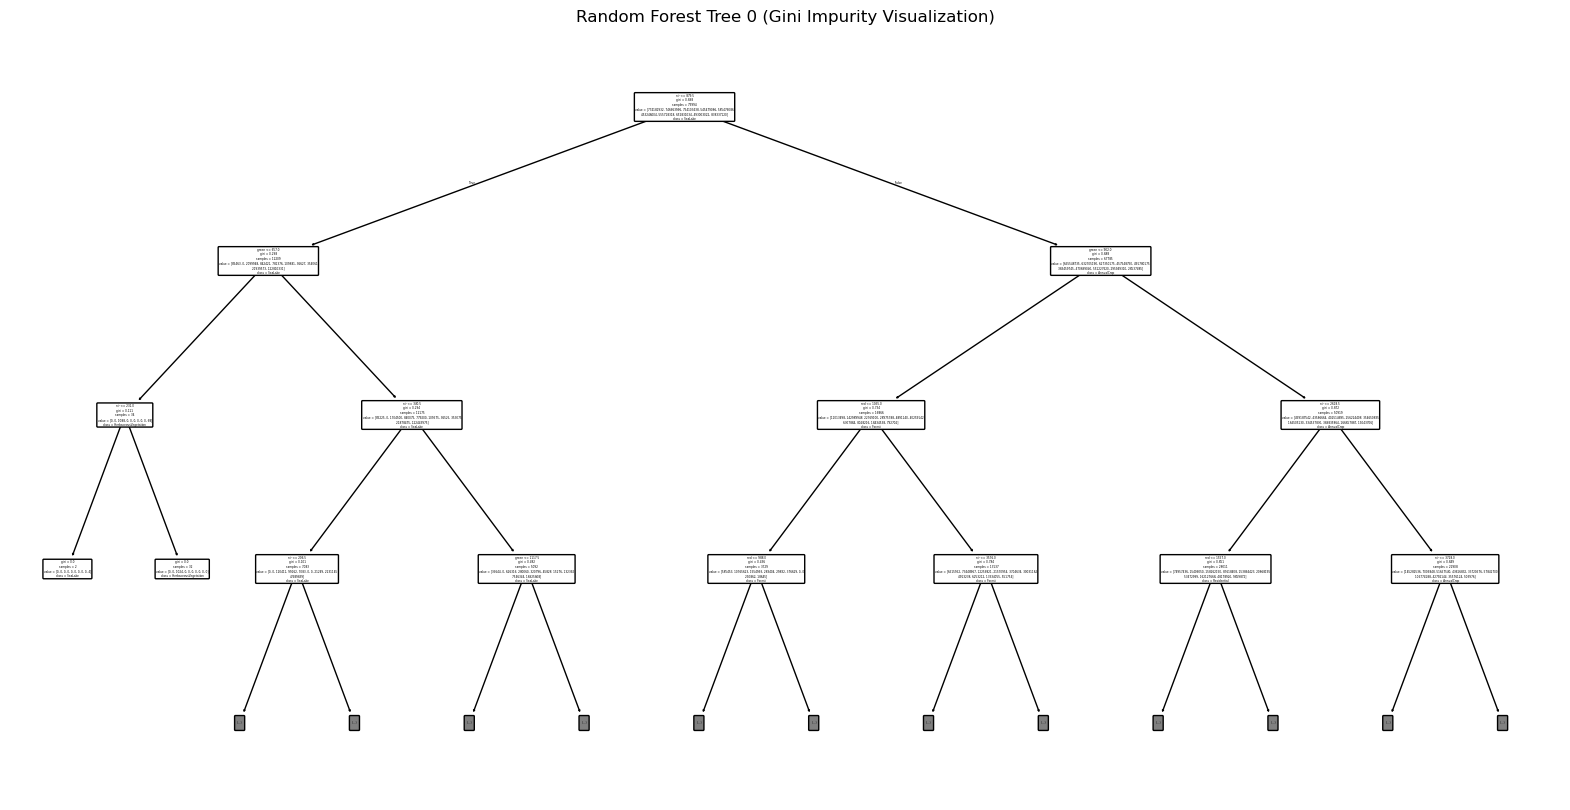

Gini impurity and sample count per node (Tree 0):
Node 0: Gini = 0.8975, Samples = 79994
Node 1: Gini = 0.2975, Samples = 12209
Node 2: Gini = 0.1107, Samples = 34
Node 3: Gini = 0.0000, Samples = 2
Node 4: Gini = 0.0000, Samples = 32
Node 5: Gini = 0.2939, Samples = 12175
Node 6: Gini = 0.1010, Samples = 7083
Node 7: Gini = 0.0040, Samples = 2021
Node 8: Gini = 0.1327, Samples = 14
Node 9: Gini = -0.0000, Samples = 10
Node 10: Gini = 0.3750, Samples = 4
Node 11: Gini = 0.0030, Samples = 2007
Node 12: Gini = 0.0020, Samples = 1995
Node 13: Gini = -0.0000, Samples = 1564
Node 14: Gini = 0.0092, Samples = 431
Node 15: Gini = 0.0196, Samples = 101
Node 16: Gini = -0.0000, Samples = 66
Node 17: Gini = 0.0555, Samples = 35
Node 18: Gini = 0.0000, Samples = 1
Node 19: Gini = 0.0000, Samples = 34
Node 20: Gini = 0.0060, Samples = 330
Node 21: Gini = 0.0644, Samples = 30
Node 22: Gini = 0.0000, Samples = 18
Node 23: Gini = 0.1528, Samples = 12
Node 24: Gini = 0.0000, Samples = 1
Node 25: Gini 

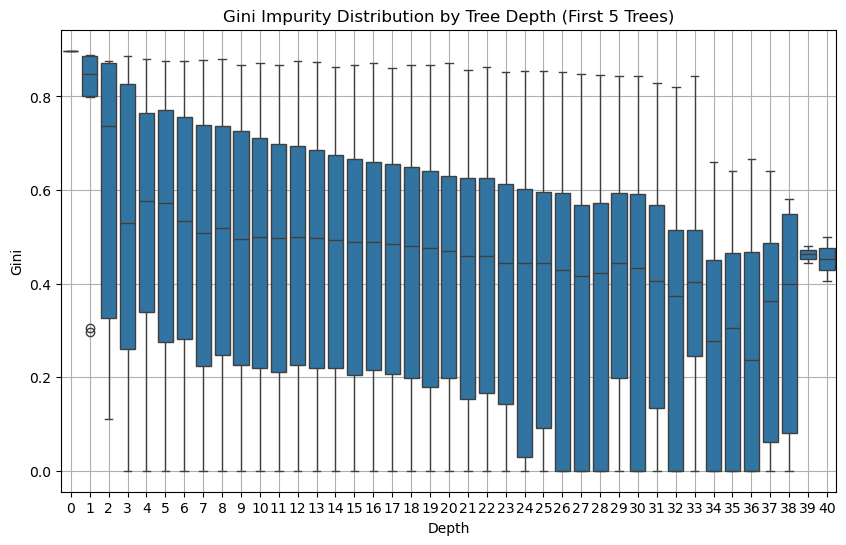

In [23]:
print("Gini tree distribution for RFC Model A")
visualize_rfc_gini(best_rfcA_estimator)

Gini tree distribution for RFC Model B


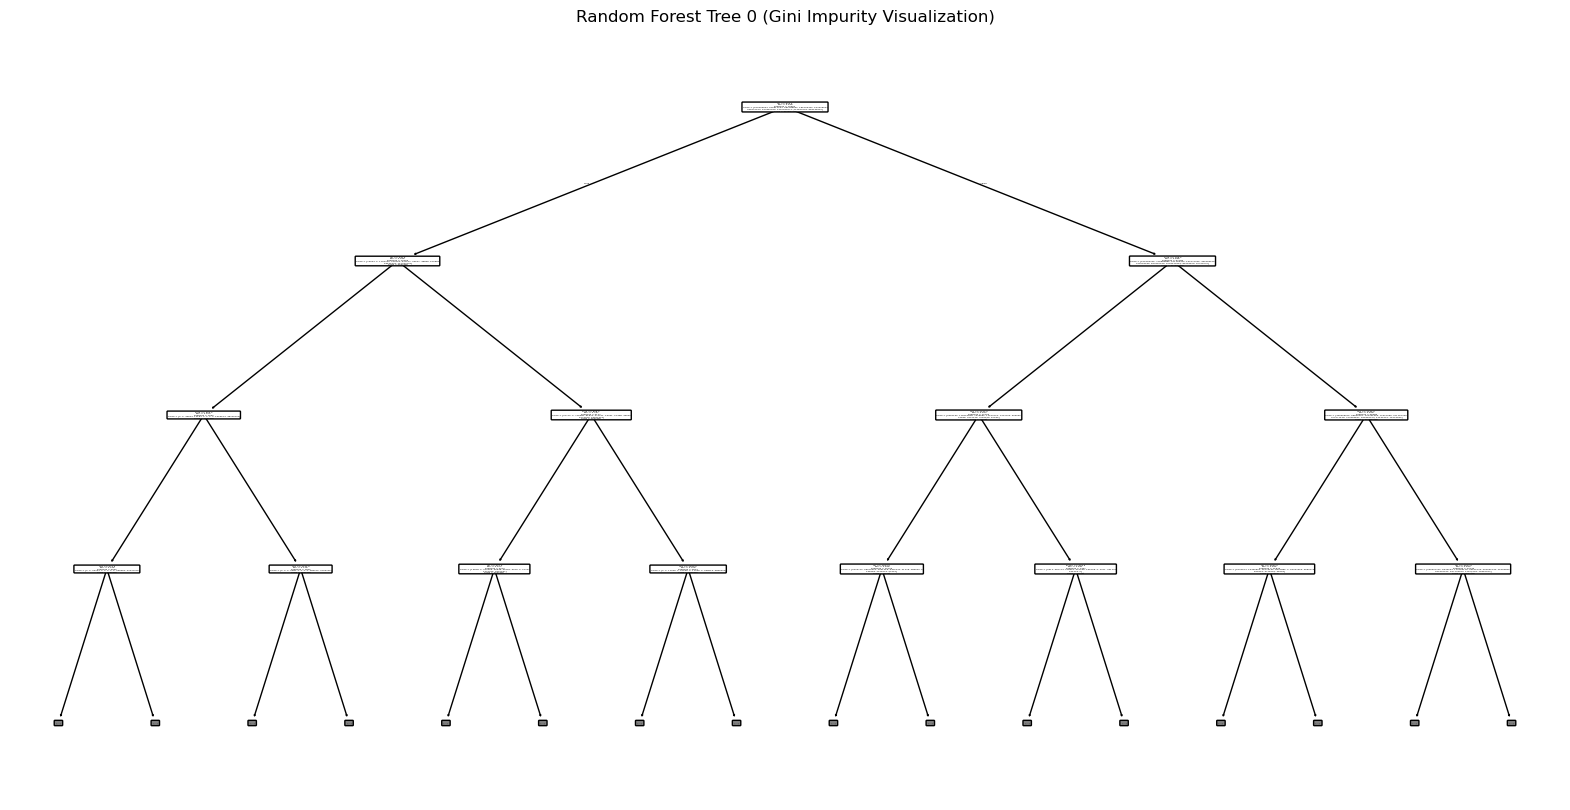

Gini impurity and sample count per node (Tree 0):
Node 0: Gini = 0.8975, Samples = 79994
Node 1: Gini = 0.2975, Samples = 12209
Node 2: Gini = 0.1027, Samples = 7092
Node 3: Gini = 0.0576, Samples = 5252
Node 4: Gini = 0.5289, Samples = 11
Node 5: Gini = 0.3457, Samples = 9
Node 6: Gini = 0.0000, Samples = 2
Node 7: Gini = 0.0000, Samples = 7
Node 8: Gini = 0.0000, Samples = 2
Node 9: Gini = 0.0544, Samples = 5241
Node 10: Gini = 0.0474, Samples = 5089
Node 11: Gini = 0.0031, Samples = 1959
Node 12: Gini = 0.1327, Samples = 14
Node 13: Gini = -0.0000, Samples = 13
Node 14: Gini = 0.0000, Samples = 1
Node 15: Gini = 0.0021, Samples = 1945
Node 16: Gini = -0.0000, Samples = 1564
Node 17: Gini = 0.0105, Samples = 381
Node 18: Gini = 0.1049, Samples = 18
Node 19: Gini = 0.3750, Samples = 4
Node 20: Gini = 0.0000, Samples = 14
Node 21: Gini = 0.0055, Samples = 363
Node 22: Gini = 0.0950, Samples = 20
Node 23: Gini = 0.0000, Samples = 343
Node 24: Gini = 0.0742, Samples = 3130
Node 25: Gini 

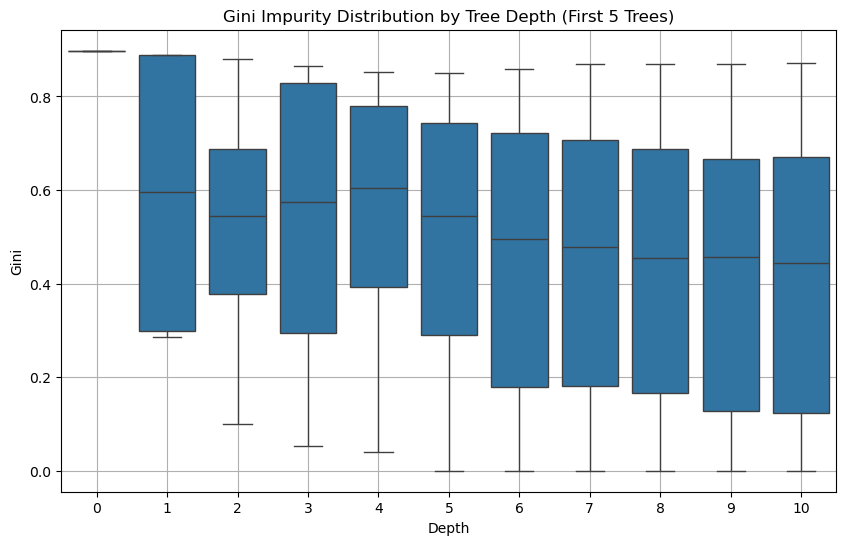

In [24]:
print("Gini tree distribution for RFC Model B")
visualize_rfc_gini(best_rfcB_estimator)

Training Accuracy for Random Forest Model A: 86.85
Overall accuracy score for Random Forest Model A: 56.32
Classification Report for Random Forest Model A:
                       precision    recall  f1-score   support

          AnnualCrop       0.51      0.54      0.52      2174
              Forest       0.69      0.89      0.78      2174
HerbaceousVegetation       0.43      0.51      0.47      2174
             Highway       0.26      0.10      0.14      1811
          Industrial       0.60      0.60      0.60      1812
             Pasture       0.54      0.62      0.57      1449
       PermanentCrop       0.41      0.42      0.41      1812
         Residential       0.41      0.52      0.46      2174
               River       0.54      0.29      0.38      1812
             SeaLake       0.94      0.95      0.95      2607

            accuracy                           0.56     19999
           macro avg       0.53      0.54      0.53     19999
        weighted avg       0.55    

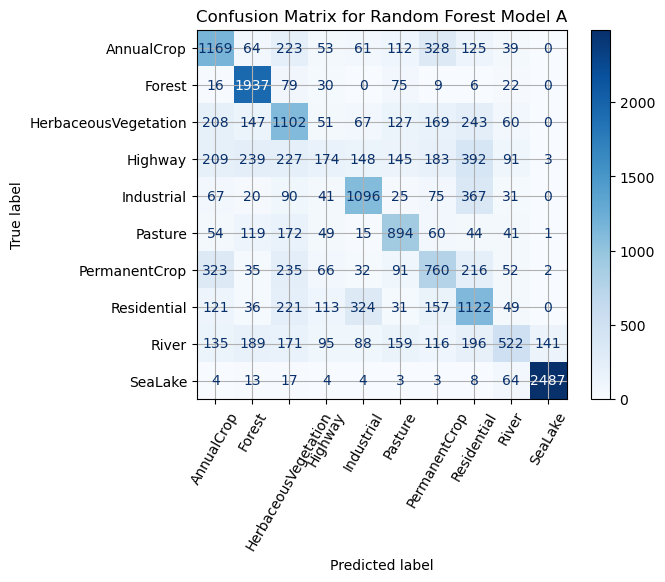

Accuracy from confusion matrix: 56.32%
ROC AUC (OvsR): 0.88


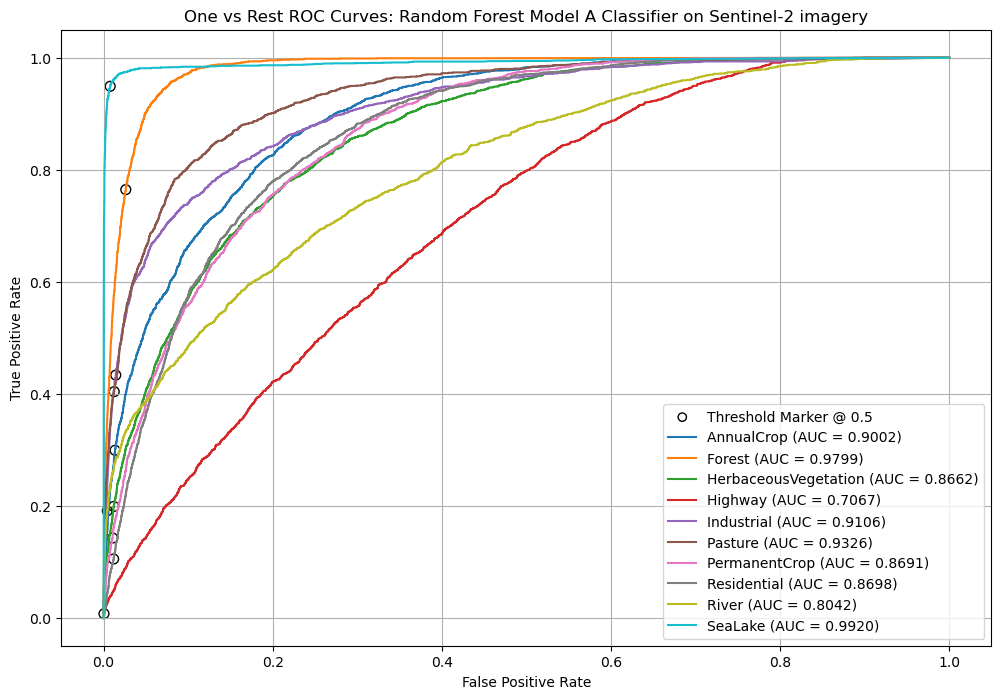

In [25]:
evaluate_model("Random Forest Model A", best_rfcA_estimator)

Training Accuracy for Random Forest Model B: 55.68
Overall accuracy score for Random Forest Model B: 53.55
Classification Report for Random Forest Model B:
                       precision    recall  f1-score   support

          AnnualCrop       0.46      0.46      0.46      2174
              Forest       0.65      0.88      0.75      2174
HerbaceousVegetation       0.38      0.48      0.42      2174
             Highway       0.24      0.05      0.08      1811
          Industrial       0.55      0.60      0.57      1812
             Pasture       0.52      0.62      0.57      1449
       PermanentCrop       0.37      0.42      0.39      1812
         Residential       0.39      0.49      0.43      2174
               River       0.63      0.21      0.32      1812
             SeaLake       0.93      0.95      0.94      2607

            accuracy                           0.54     19999
           macro avg       0.51      0.52      0.49     19999
        weighted avg       0.52    

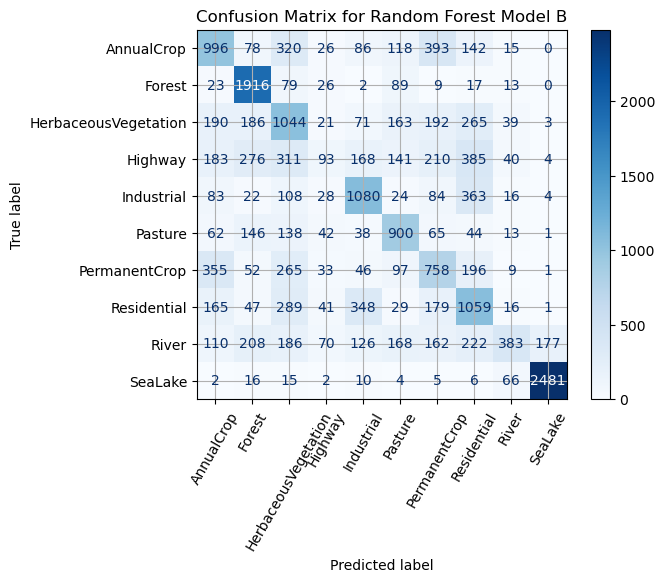

Accuracy from confusion matrix: 53.55%
ROC AUC (OvsR): 0.87


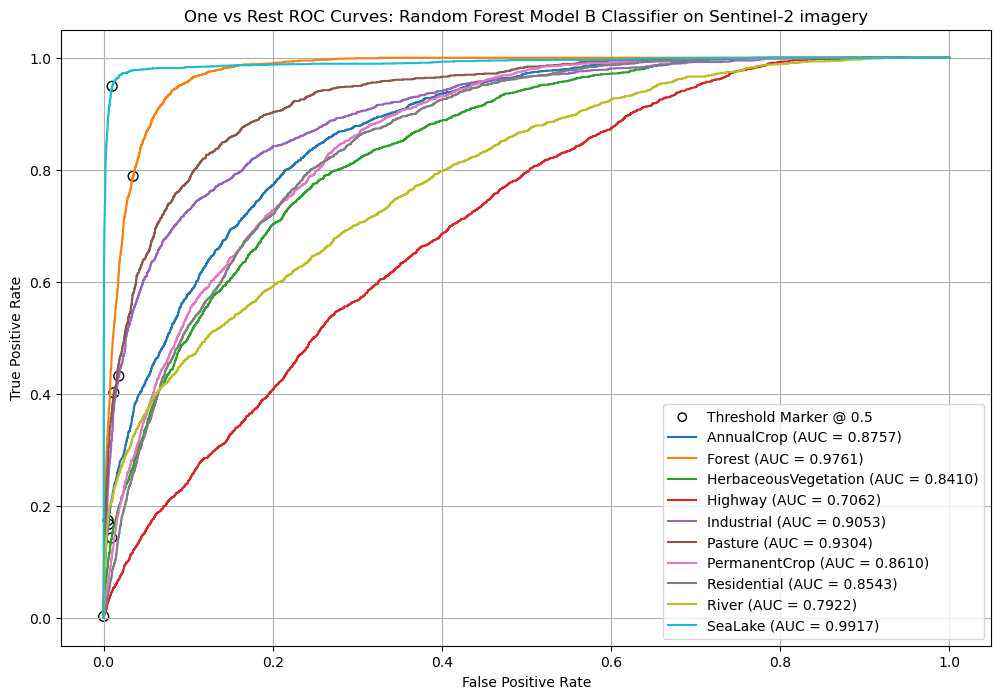

In [26]:
evaluate_model("Random Forest Model B", best_rfcB_estimator)

**RFC Model A Results** \
{'n_estimators': 250, 'min_samples_split': 10, 'max_features': 1, 'max_depth': None} \
Optimized Random Forest Classification Training Accuracy: 86.85% \
Optimized Random Forest Classification Testing Accuracy: 56.32% 

**RFC Model B Results** \
{'n_estimators': 100, 'min_samples_split': 5, 'max_features': 4, 'max_depth': 10} \
Optimized Random Forest Classification Training Accuracy: 55.68% \
Optimized Random Forest Classification Testing Accuracy: 53.55% 


**RFC Models overfitting and accuracy comparison** \
Based on the high training accuracy and significantly lower testing (overall) accuracy, it can be stated with certainty that the Random Forest Classfication (RFC) Model A severely overfitted. The similar training and testing (overall) accuracy showcased by RFC Model B indicates good generalization with minimal overfitting. The reason RFC Model B generalized significantly better comes down to the maximum tree depth allowed during the tuning of the model. Based on the assignments and some testing, it appears that if a RFC model is provided to option to extend it's tree depth as far as possible (i.e. max_depth = None), it will gladly do so to maximize the scoring parameter. 

While RFC Model A does have an better training and testing accuracy, there is a high likelihood that it would fail or at the very least have very low testing accuracy on new unseen data, especially if any distribution shifts occur, such as seasonal or lighting differences within the Sentinel-2 imagery. RFC Model B on the other hand may have a slightly lower testing score, but it generalizes much better with minimal difference in the ROC AUC curves, resulting in a more reliable model. 

**RFC Models ROC and AUC curves comparison** \
Looking at the ROC curves with thresholds set to 0.5 (default) per class, it is notable that the ROC AUC value dropped one percentage point between Model A and Model B, respectively. All of the AUC curve values also dropped slightly, some, like Annual Crop, dropped more than others, like Sea Lake. The drop in ROC AUC (OvsR) value can be explained by the decrease in testing accuracy, as can the AUC curve values drop. 

Most of the 0.5 thresholds for both models are near the far-lower-left part the curves (near 0). This indicates that the models contain suboptimal calibration, which can result in the divergence of the accuracy and AUC showcased here. One positive is that most of the curves rise quickly with minimal rightward movement, along with the far-left threshold position, indicates that the models are capable of, and, in most cases, provide low false positive rates (i.e. the precision is under control). If one of these models were to be put into production, we'd want to tune the theshold per class to optimize the recall and precision (i.e. be as close as possible to the upper-left corner). 

While some classes, like SeaLake and Forest, show near-perfect ROC cruves and separability, others, such as Highway, have a fanned out curve, indicating potential overlap with other classes in feature space (Ex: Trees or pastureland overlapping or near a highway). Another potential and overlapping reason why some clases performed much better than others in both models is due to the size of the features and the 10m resolution of the imagery. Smaller or narrower land features, such as a highway or river may only cover 1 to 2 pixels in width, making them less prevalent in the imagery and more likely be contained in 'mixed pixels' rather than 'pure pixels', diluting the clarity of the pixel belonging to a given class in feature space. Larger and easily differentiable land features, such as AnnualCrop and Forest would inherently do better due to their discernable features in feature space, while land cover types, such as HerbaceousVegetation and Pasture land are more similar in RGBN pixels, making them less discernable in feature space. This easily explains why Highway and River classes struggled so much. Textural modeling would need to be implemented to help with such discernments. Rivers tend to vary quite a bit in colour and in particulate matter, leading to large variations in RGBN band values. This large variation makes rivers, and sometimes lakes, quite difficult to classify, and explains why both models struggled with this class. 

**RFC Models Confusion Matrices comparison**

Confusion Matrix Accuracy % for Model A = 56.32%
Confusion Matrix Accuracy % for Model B = 53.55%

The above confusion matrix accuracy clearly shows the Model A slightly outperformed with the accuracy of 56.32% as the Model B has around 53.55% 
Model A has performed well in predicting classes like Forest, Herbaceous Vegetation and Sealake with high positive counts. But it has struggled with differentiating between classes Residential vs River, and AnnualCorp vs Pasture
Model B has shown clear classes discrimination in some classes but frequent misclassifications between similar classes suca has AnnnualCorp and PermanentCorp and Rver and Residential. 

Both the models has shown strong performance in predicting the SeaLake  and Forest classes with minimal errors.
Both the models shows Highway class as the most confused class ,more so in the Model B. 

**RFC Models f1-score, recall, and precision results and comparison** \
Model A slightly outperforms Model B in terms of **macro and weighted averages**, with a macro F1-score of 0.53 versus 0.49 and a weighted F1-score of 0.55 versus 0.51. ie Model A handles class balances slightly better and has a more consistent performance across all classes. 
In terms of **precision**, Model A again leads with weighted average of 0.55 compared to 0.52 in Model B suggesting fewer false positives overall.
**Recall scores** are also higher for Model A (weighted avg: 0.56) than Model B (0.54), which suggests Model A has greater ability to correctly identify true positives, particularly in classes like SeaLake (f1 score - 95%) and Forest (f1 score - 78%).
But you can see that Model B provides a balanced generalization between classes as its f1 scores are comparable and doesnt show stark contrast scores unlike in Model A

Both of the models struggle with classes such as Highway, River, and Herbaceous Vegetation, indicating the need for further data tuning.


**RFC Models Ginne Impurity values per tree** \
Model A and Model B differ significantly in their tree structures and impurity profiles. Model A builds deeper trees up to a max depth of 40, showing a steady decline in Gini impurity with depth. This indicates a steady decline within the Gini impurity with depth, indicating increasingly pure splits and high risk of overfitting due to complex tree growth. 
But in Model B tree depth is limited to the maximum depth of 10, resulting in a more compact and interpretable model. Its impurity values, however, are relatively higher across all depths, which points to underfitting or less effective splits. 
In short, Model A shows learning complex patterns, while Model B shows simplicity and generalization potentially at the cost of performance.

## SVC Model Results

Training Accuracy for Support Vector Machine: 52.33
Overall accuracy score for Support Vector Machine: 51.93
Classification Report for Support Vector Machine:
                       precision    recall  f1-score   support

          AnnualCrop       0.44      0.53      0.48      2174
              Forest       0.60      0.88      0.72      2174
HerbaceousVegetation       0.37      0.37      0.37      2174
             Highway       0.23      0.03      0.06      1811
          Industrial       0.60      0.57      0.58      1812
             Pasture       0.52      0.60      0.56      1449
       PermanentCrop       0.39      0.37      0.38      1812
         Residential       0.35      0.58      0.44      2174
               River       0.59      0.05      0.09      1812
             SeaLake       0.84      0.97      0.90      2607

            accuracy                           0.52     19999
           macro avg       0.49      0.50      0.46     19999
        weighted avg       0.50 

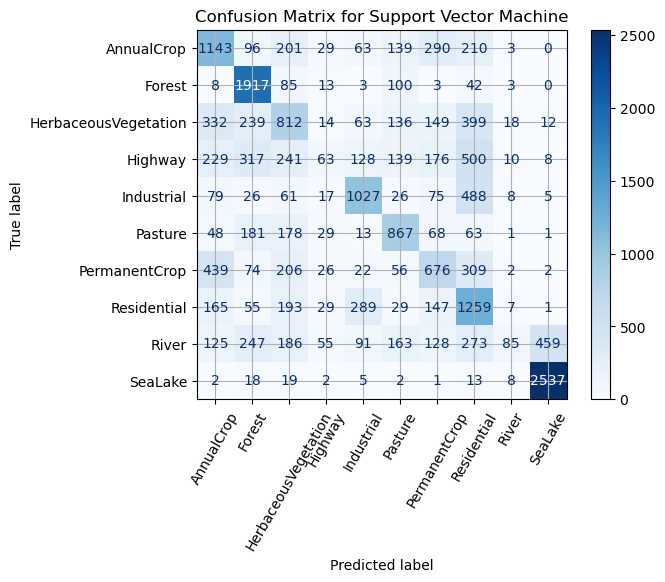

Accuracy from confusion matrix: 51.93%
ROC AUC (OvsR): 0.83


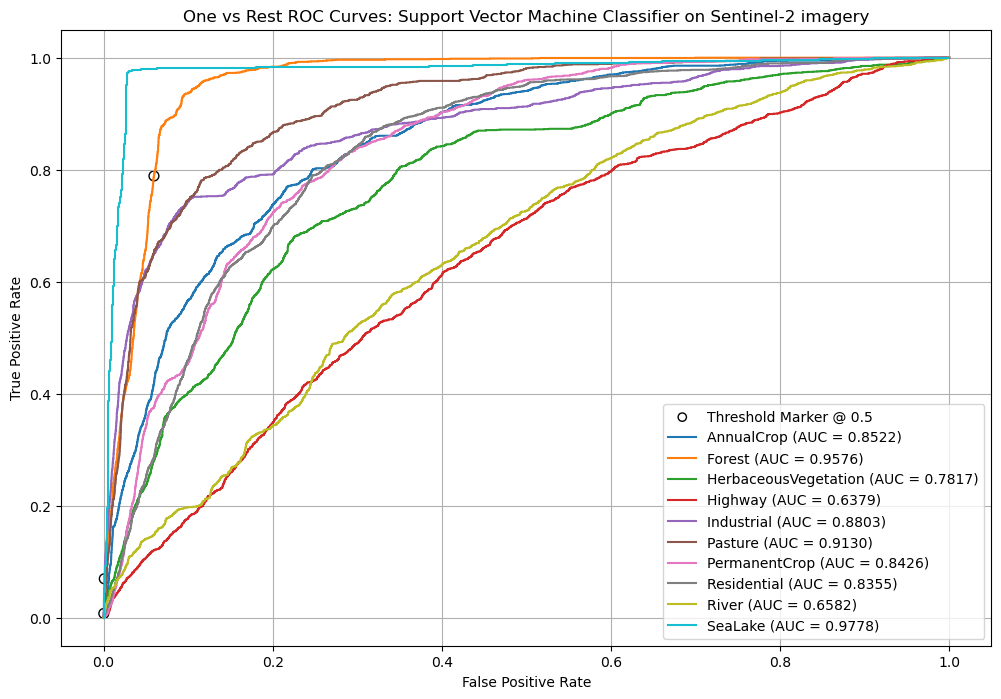

In [27]:
evaluate_model("Support Vector Machine", best_svc_estimator)

**SVC Model Results** 
{'svc__C': np.float64(4.821125680265211), 'svc__gamma': np.float64(0.04363677705546425), 'svc__kernel': 'rbf'} \
Optimized Support Vector Classification Training Accuracy: 52.33% \
Optimized Support Vector Classification Testing Accuracy: 51.93%

**SVC Model overfitting and accuracy** 

As configured, the SVC model performed slightly "better than a best guess", that is the model generated an accuracy score 52.33% for training data and 51.93% overall. This suggests that the model is underfitted and that it cannot accurately distinguish between the various classes of data. Enhancing feature engineering or additional model tuning could help boost performance for weaker classes.

**F1-score, precision and recall**

The F1 scores from the Support Vector Machine model reveal mixed performance across classes. It performs very well on SeaLake (F1-score: 0.90) and Forest (F1-score: 0.72), indicating strong precision and recall for these categories.  In contrast, several classes show weak F1 scores -- particularly Highway (0.06) and River (0.09) -- which reflect poor recall and high misclassification rates. These low scores imply that the model struggles to distinguish these classes from others. Other classes -- such as HerbaceousVegetation, PermanentCrop, and Residential -- fall in the moderate range (F1-scores between 0.37 and 0.44), suggesting inconsistent performance. The macro average F1-score of 0.46 and weighted average of 0.48 confirm that the model is underperforming, with accuracy hovering around 52%. While it succeeds in identifying a few dominant classes, it fails to generalize well across all categories.

Similarly, precision and recall scores bolster the findings observed in the F1-scores. That is, they demonstate that the model varies significantly across classes, with SeaLake and Forest showing strong performance -— SeaLake achieves a precision of 0.84 and recall of 0.97, while Forest generates a precision score of 0.60 and a recall score of 0.88 recall -- indicating the model is highly effective at identifying these categories. In contrast, classes like Highway and River exhibit poor recall (0.03 and 0.05 respectively), meaning the model fails to correctly identify most instances of these types. At 0.49 and 0.50, the macro average precision and recall socres reflect the model’s uneven performance across classes. This imbalance suggests the model may benefit from class-specific tuning or other remedial actions.


**SVC Model's ROC and AUC curves** 

AUC scores indicate that the model performs well overall, with several classes -- such as lake, forest, and pasture -- showing excellent classification performance (AUC > 0.90). These scores suggest that the model can reliably distinguish these classes due to their distinct features and consistency. Other categories -- including AnnualCrop, Industrial, PermanentCrop, and Residential -- also show good performance (AUC ~0.83–0.88). However, the model's performance may have suffered due to overlapping characteristics with other classes that made them more challenging to separate.

However, the model struggles with classes like HerbaceousVegetation, Rivers, and Highways, which have notably lower AUC scores (0.78, 0.66, and 0.64, respectively). These results suggest that these classes likely have notable similarities to other classes, or may be underrepresented in the training data. For example, data in the highway class may resemble data in the Industrial or Residential classes, while data in River class may resemble SeaLake or HerbaceousVegetation classes. More than likely, however, this results due to the reason mentioned in the RFC Models ROC and AUC Curves Comparison section (small feature sizes resulting in mixed-class pixels)..

**Confusion Matrix**

The confusion matrix for the Support Vector Classifier (SVC) model corroborates the previously discussed performance metrics. The SeaLake class exhibited the highest number of true positive predictions (2,537), followed by Forest (1,917) and AnnualCrop (1,143), indicating strong model performance in these categories. Conversely, the River (85) and Highway (63) classes recorded the lowest true positive counts, reflecting the model’s limited ability to accurately classify these classes.

## kNN Model Results

Training Accuracy for k-Nearest Neighbors: 99.91
Overall accuracy score for k-Nearest Neighbors: 54.83
Classification Report for k-Nearest Neighbors:
                       precision    recall  f1-score   support

          AnnualCrop       0.48      0.53      0.51      2174
              Forest       0.69      0.88      0.77      2174
HerbaceousVegetation       0.42      0.49      0.45      2174
             Highway       0.21      0.10      0.14      1811
          Industrial       0.58      0.56      0.57      1812
             Pasture       0.53      0.61      0.57      1449
       PermanentCrop       0.40      0.41      0.40      1812
         Residential       0.40      0.44      0.42      2174
               River       0.50      0.30      0.38      1812
             SeaLake       0.94      0.96      0.95      2607

            accuracy                           0.55     19999
           macro avg       0.52      0.53      0.52     19999
        weighted avg       0.53      0.55

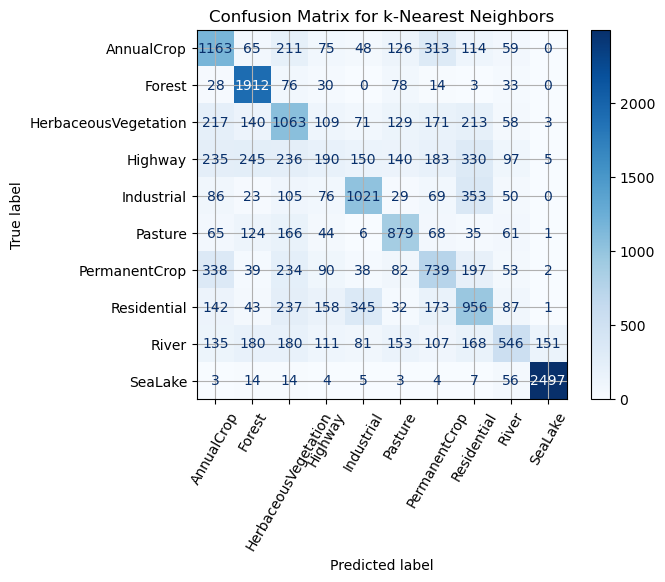

Accuracy from confusion matrix: 54.83%
ROC AUC (OvsR): 0.85


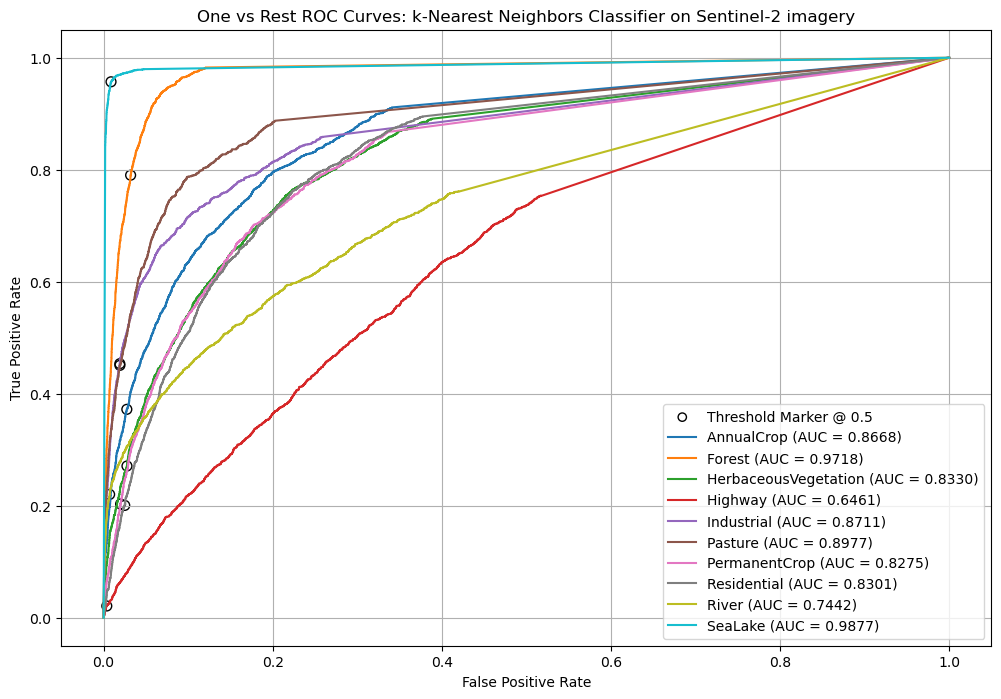

In [28]:
evaluate_model("k-Nearest Neighbors", best_knn_estimator)

**KNN Model Results**

{'knn__weights': 'distance', 'knn__n_neighbors': 11, 'knn__metric': 'euclidean'} \
Optimized k-Nearest Neighbor Classification Training Accuracy: 99.91% \
Optimized k-Nearest Neighbor Classification Testing Accuracy: 54.83% 

**KNN Model overfitting**

The K-Nearest Neighbors (KNN) model showed signs of significant overfitting, achieving a near-perfect training accuracy of 99.91% with a much lower test accuracy of 54.83%. This gap suggests the model memorized the training data rather than learning generalizable patterns. While the overall accuracy is slightly better than random chance, the performance remains limited in its ability to separate all land cover classes reliably. The model's distance-based approach likely struggled with overlapping feature distributions.

**F1-score**

F1 scores for the KNN model show high variance across different classes. SeaLake (F1-score: 0.95) and Forest (F1-score: 0.77) stand out as well-classified categories, with strong recall and precision. SeaLake, for example, achieved both high recall (0.96) and precision (0.94), meaning the model correctly identified most SeaLake samples and made very few incorrect SeaLake predictions.

In contrast, classes like Highway (F1-score: 0.14) and River (F1-score: 0.38) performed poorly. Highway had very low recall (0.10), meaning many true Highway samples were missed, and low precision (0.21), indicating many false positives. River also suffered from poor recall (0.30), which implies that the model frequently misclassified River pixels as other categories.

Other classes, such as HerbaceousVegetation (F1-score: 0.45), Residential (0.42), and PermanentCrop (0.40), had middling precision and recall, indicating inconsistent performance. The macro average F1-score of 0.52 and weighted average of 0.53 reflect this inconsistency and confirm that the model fails to generalize well across most classes, despite strong results in a few.

**KNN Model ROC and AUC values and curve results**

The AUC scores from the KNN model highlight its uneven classification ability. Classes such as SeaLake (AUC: 0.9877), Forest (0.9718), and Pasture (0.8977) had excellent separability, suggesting distinct visual or spectral characteristics. Other well-performing categories include Industrial (0.8711), AnnualCrop (0.8668), and PermanentCrop (0.8275), where the model could distinguish features with moderate success.

In contrast, classes like Highway (AUC: 0.6463) and River (0.7442) showed lower AUC values, implying frequent misclassification and overlap with other categories. These weak results may stem from visual similarities between River and SeaLake or Highway and Industrial/Residential zones.

**Confusion Matrix**

The confusion matrix supports the above findings. SeaLake achieved the highest true positives (2,497), followed by Forest (1,912) and AnnualCrop (1,163), reinforcing the model’s strength with these categories. On the other hand, River (545) and Highway (190) had lower correct prediction counts, suggesting difficulty in isolating these classes. The dispersion of misclassified values across similar classes also reflects the model’s sensitivity to unscaled distances and lack of generalization.

# RFC, SVC, and kNN Model Results Comparison

To effectively evaluate models performance, test results for each model are displayed together for clear comparison. 

In [29]:
# Create a dictionary of our final, optimized models for easy iteration
final_models = {
    "RFC (Model A)": best_rfcA_estimator,
    "RFC (Model B)": best_rfcB_estimator,
    "Support Vector Classifier": best_svc_estimator,
    "K-Nearest Neighbors": best_knn_estimator
}

# --- 1. Calculate All Metrics and Build Summary Table ---
print("--- 1. Comprehensive Performance Summary ---")

training_times = [elapsed_time_rfcA, elapsed_time_rfcB, elapsed_time_svc, elapsed_time_knn]
training_accuracies = [training_accuracy_rfcA, training_accuracy_rfcB, training_accuracy_svc, training_accuracy_knn]
testing_accuracies = [testing_accuracy_rfcA, testing_accuracy_rfcB, testing_accuracy_svc, testing_accuracy_knn]

summary_data = []
all_predictions = {}
y_test_binarized = label_binarize(y_test, classes=np.arange(len(class_labels)))
n_classes = y_test_binarized.shape[1]

for i, (model_name, model) in enumerate(final_models.items()):
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)
    all_predictions[model_name] = y_pred

    f1 = f1_score(y_test, y_pred, average='macro')
    auc_score_val = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')

    gap = training_accuracies[i] - testing_accuracies[i]
    generalization = "Poor (Overfit)" if gap > 0.1 else "Good"
        
    summary_data.append({
        "Model": model_name,
        "Train Accuracy": f"{training_accuracies[i]:.2%}",
        "Test Accuracy": f"{testing_accuracies[i]:.2%}",
        "Accuracy Gap": f"{gap:.2%}",
        "Macro F1-Score": f"{f1:.4f}",
        "Macro AUC": f"{auc_score_val:.4f}",
        "Training Time (s)": f"{training_times[i]:.2f}",
        "Generalization": generalization
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

--- 1. Comprehensive Performance Summary ---
                    Model Train Accuracy Test Accuracy Accuracy Gap Macro F1-Score Macro AUC Training Time (s) Generalization
            RFC (Model A)         86.85%        56.32%       30.53%         0.5281    0.8831             24.60 Poor (Overfit)
            RFC (Model B)         55.68%        53.55%        2.13%         0.4934    0.8734              9.53           Good
Support Vector Classifier         52.33%        51.93%        0.40%         0.4586    0.8337           2599.55           Good
      K-Nearest Neighbors         99.91%        54.83%       45.08%         0.5158    0.8476              4.53 Poor (Overfit)




--- 2. Comparative ROC Curve Analysis ---


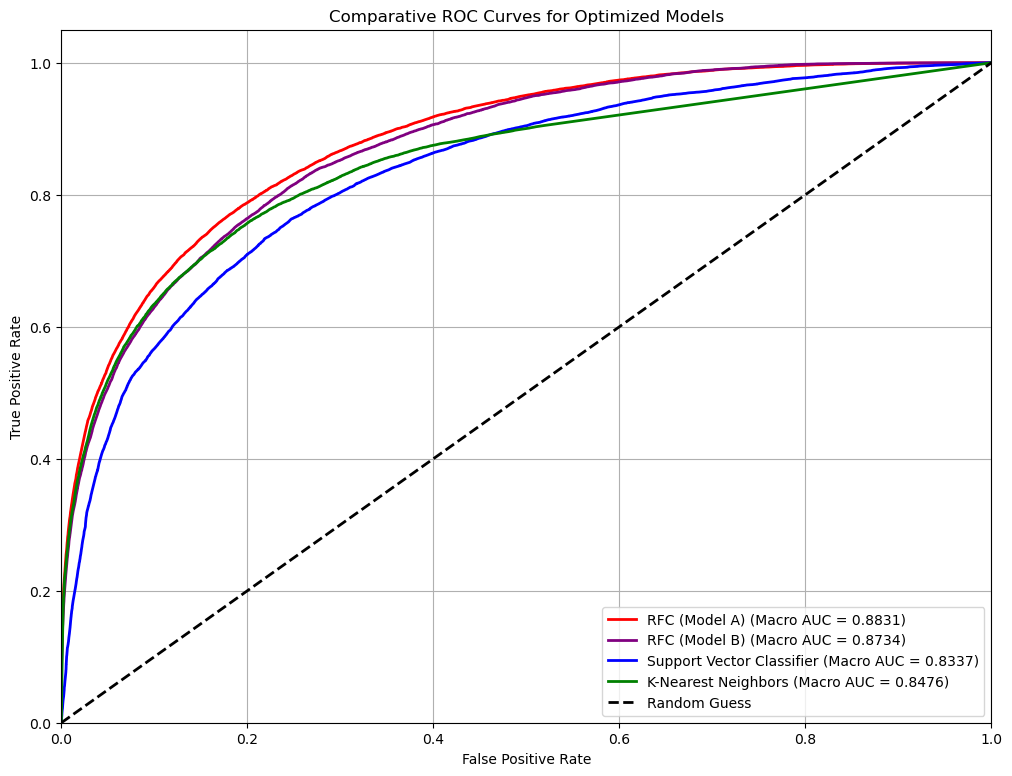

In [30]:
# --- 2. Comparative ROC Curve Plot ---
print("\n\n--- 2. Comparative ROC Curve Analysis ---")

plt.figure(figsize=(12, 9))
colors = cycle(['red', 'purple', 'blue', 'green'])

for model_name, model in final_models.items():
    y_score = model.predict_proba(X_test)
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc_macro = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, color=next(colors), lw=2,
             label=f'{model_name} (Macro AUC = {roc_auc_macro:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Comparative ROC Curves for Optimized Models')
plt.legend(loc="lower right"); plt.grid(True)
plt.show()



--- 3. Generating Learning Curves ---


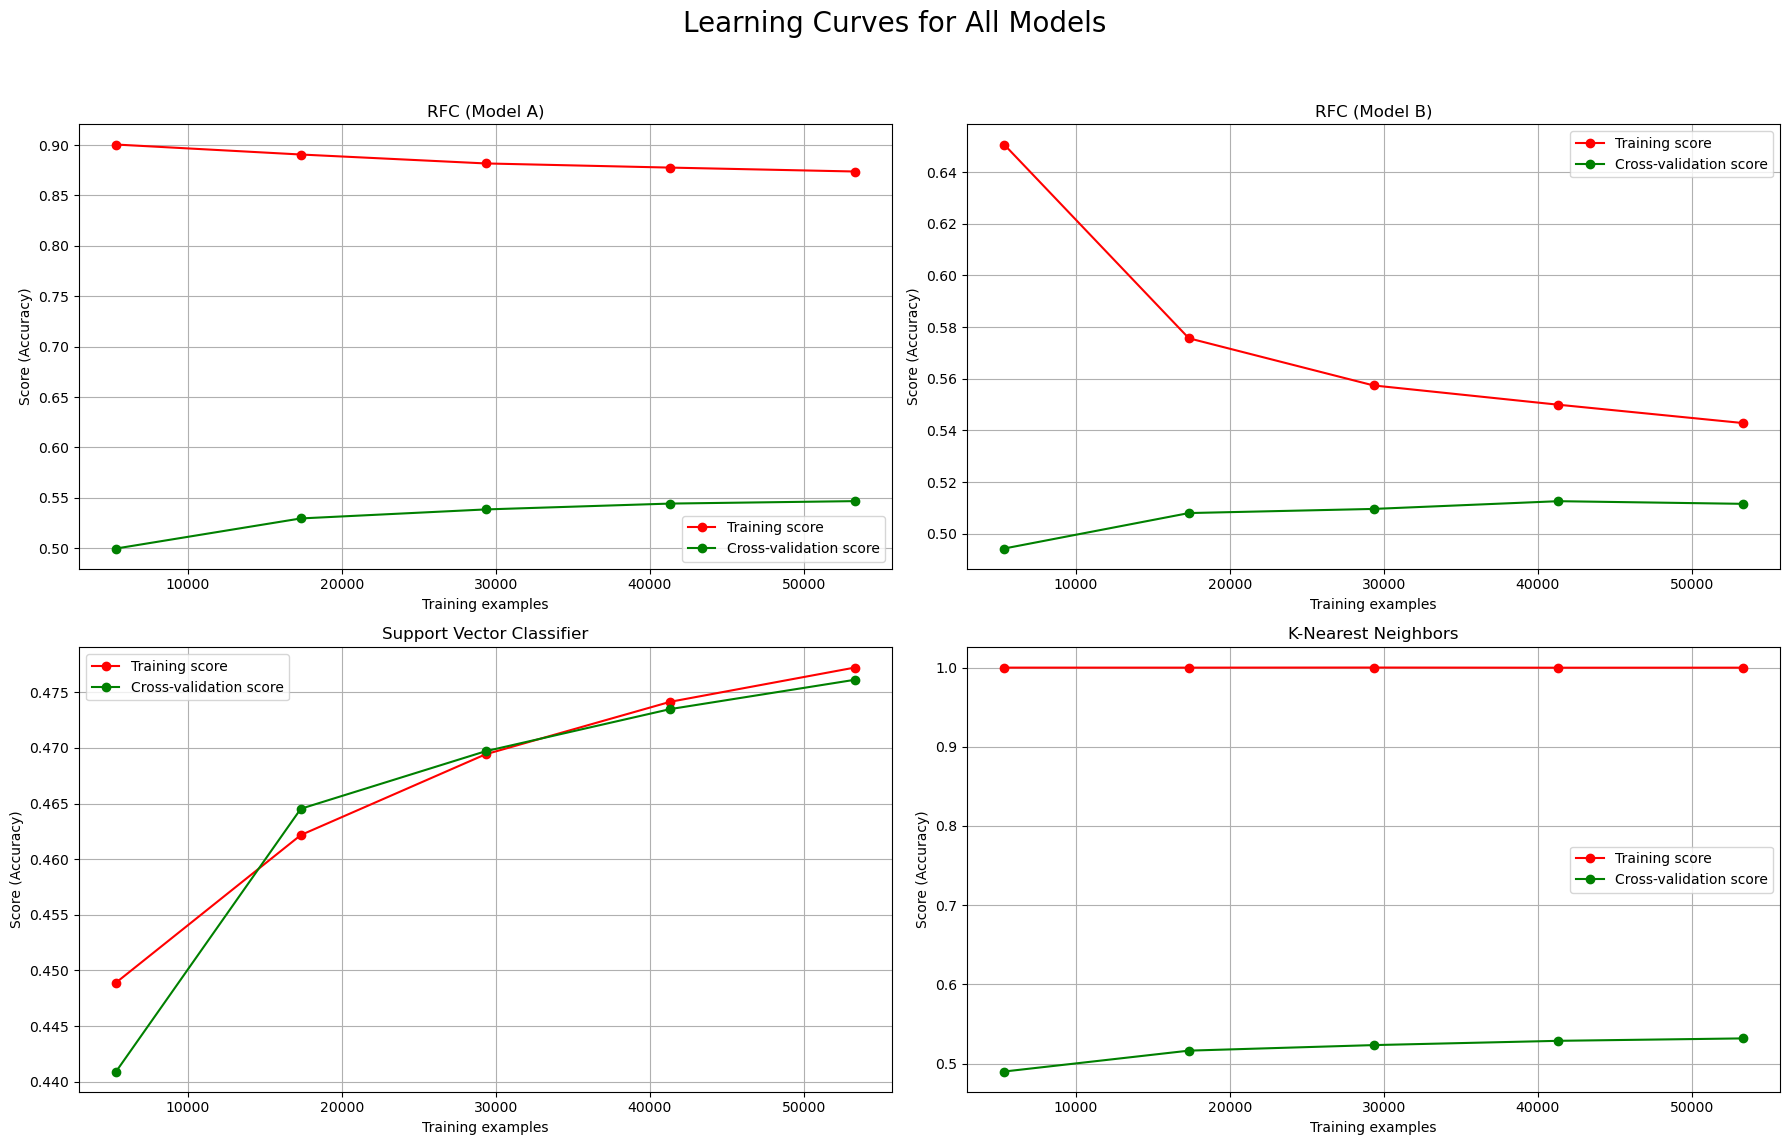

In [31]:
# --- 3. Learning Curves in a 2x2 Grid ---
print("\n\n--- 3. Generating Learning Curves ---")

def plot_learning_curve_subplot(ax, estimator, title, X, y, cv=3, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Score (Accuracy)")
    ax.grid()
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='f1_weighted')
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    ax.legend(loc="best")
    return ax

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Learning Curves for All Models', fontsize=20)
axes = axes.flatten()

for i, (model_name, model) in enumerate(final_models.items()):
    plot_learning_curve_subplot(axes[i], model, model_name, X_train, y_train, cv=3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



--- 4. Comparative Confusion Matrices ---


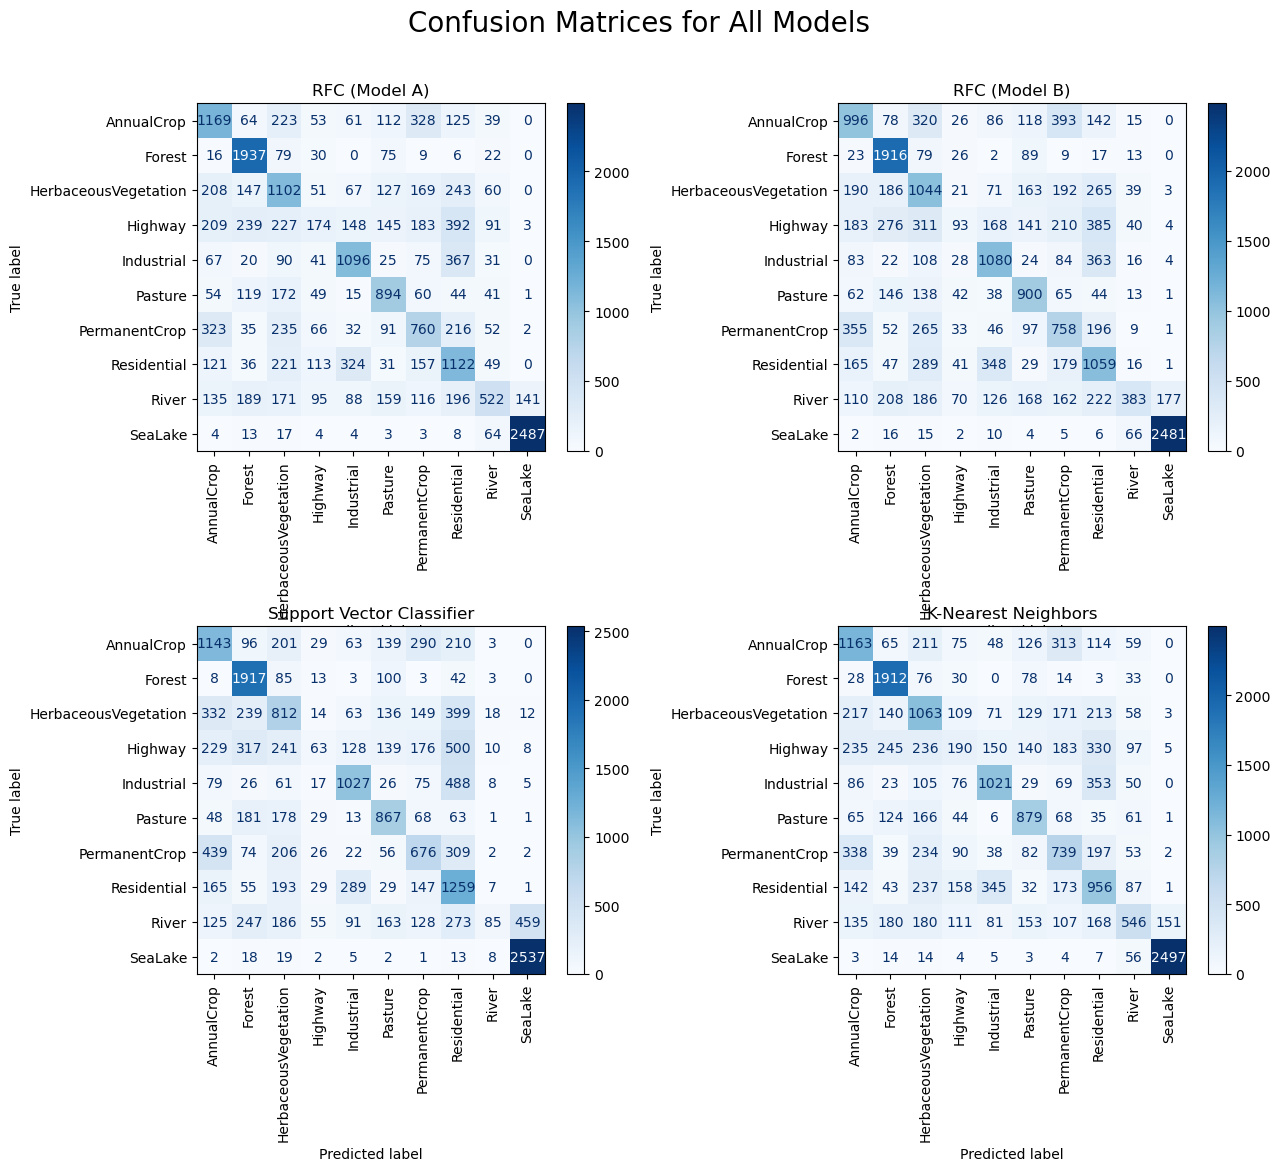

In [32]:
# --- 4. Comparative Confusion Matrices (2x2 Grid) ---
print("\n\n--- 4. Comparative Confusion Matrices ---")
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=20)
axes = axes.flatten()

for i, (model_name, model) in enumerate(final_models.items()):
    cm = confusion_matrix(y_test, all_predictions[model_name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=axes[i], xticks_rotation='vertical', cmap=plt.cm.Blues)
    axes[i].set_title(model_name)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Comparative Analysis:
* **Generalization**: Random Forest (rfcB) and SVC generalized well, while KNN and Random Forest (rfcA) significantly overfit.
* **Overall Performance**: Random Forest (rfcB) was the best overall choice due to its balanced and trustworthy performance, outperforming SVC, KNN, and overfit Random Forest (rfcA) despite their sometimes high scores.
* **Computational Cost**: Random Forest models (rfcB and rfcA) were efficient, KNN was the fastest since it only performance memorization during the training phase, while SVC was significantly slower.
* **Class-Specific Performance**: SVC struggled with linear features having the lowest performance on Rivers and Highways. On the same two classes KNN and Random Forest (rfcA) showed deceptively better F1 scores, but results are most likely due to memorization.
* **Suitability**: Random Forest (rfcB) was the most practical and effective choice, whereas SVC was not the right tool due to high cost and poor critical class performance, and KNN and Random Forest (rfcA) were unsuitable due to severe overfitting and poor generalization.
* **Consistent Struggles**: All models consistently struggled with Highway, River, and Herbaceous Vegetation.
* **Consistently Well-Predicted**: All models consistently well-predicted SeaLake and Forest.

In conclusion, while multiple models can be applied to the problem, the well-generalized Random Forest provides the most trustworthy and balanced performance, although further work is needed to address the significant class imbalance to improve performance on rare classes.